In [1]:
import os
import re
import sys
import time
import getopt
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.append("/home/users/mnergiz/softwares/licsar_extra/python")  # adjust as needed
import datetime as dt
from lics_tstools import load_licsbas_cumh5_as_xrda
from lics_tstools import generate_pmm_velocity
from lics_tstools import load_tif2xr

snaphu not detected. please install it yourself, e.g. from:
https://web.stanford.edu/group/radar/softwareandlinks/sw/snaphu
setting pyproj data directory
licsar misc not loaded
licsbas not loaded - the amplitude/coherence average/stability will fail


/home/users/mnergiz/.conda/envs/licsbas_jasmin/lib/python3.10/site-packages/pyproj/datadir.py:38: UserWarning: pyproj unable to set PROJ database path.
  _set_context_data_dir()


In [2]:
def da_to_xyz(da, out_path, varname=None):
    # Standardize coord names
    if "x" in da.dims: da = da.rename({"x": "lon"})
    if "y" in da.dims: da = da.rename({"y": "lat"})
    if "longitude" in da.dims: da = da.rename({"longitude": "lon"})
    if "latitude" in da.dims:  da = da.rename({"latitude":  "lat"})

    name = varname or (da.name if da.name else "z")
    da = da.rename(name)

    # Flatten -> DataFrame (lon, lat, value)
    df = (
        da.stack(pt=("lat", "lon"))
          .to_series()
          .dropna()
          .reset_index()
          .rename(columns={name: "value"})
          [ ["lon", "lat", "value"] ]
    )

    # Create parent dir only if one was provided
    parent = os.path.dirname(out_path)
    if parent:
        os.makedirs(parent, exist_ok=True)

    # Write XYZ (space-separated, no header)
    df.to_csv(out_path, sep=" ", header=False, index=False)


In [3]:
def _get_pixel_window(da, reference, halfwin=4):
    """
    Return a subset window around the nearest pixel to (lon, lat).

    halfwin=4 means:
      x: ix-4 ... ix+4
      y: iy-4 ... iy+4
    i.e. a 9x9 window.
    """
    lon0, lat0 = reference

    # nearest pixel index
    ix = int(np.abs(da.lon.values - lon0).argmin())
    iy = int(np.abs(da.lat.values - lat0).argmin())

    # clip to image boundaries
    x1 = max(0, ix - halfwin)
    x2 = min(da.sizes["lon"], ix + halfwin + 1)
    y1 = max(0, iy - halfwin)
    y2 = min(da.sizes["lat"], iy + halfwin + 1)

    return da.isel(lon=slice(x1, x2), lat=slice(y1, y2))


def spatial_reference_2d(da, reference, use_nearest=False, halfwin=4):
    """
    Spatially reference a 2D DataArray (lat, lon) to a point
    or to the mean of a pixel window around that point.

    Parameters
    ----------
    da : xarray.DataArray
        2D array with dims (lat, lon)
    reference : tuple
        (lon, lat)
    use_nearest : bool
        If True, use nearest single pixel.
        If False, use mean over window defined by halfwin.
    halfwin : int
        Half window size in pixels. halfwin=4 => 9x9 window.
    """
    da = da.where(da != 0)

    if use_nearest:
        ref_val = da.sel(lon=reference[0], lat=reference[1], method="nearest")
    else:
        ref_win = _get_pixel_window(da, reference, halfwin=halfwin)
        ref_val = ref_win.mean(dim=("lat", "lon"), skipna=True)

    if np.isnan(ref_val.values):
        ref_val = da.sel(lon=reference[0], lat=reference[1], method="nearest")

    return da - ref_val


def reference_ts_dataset(ds, reference, vars_to_ref=None, use_nearest=False, halfwin=4, verbose=True):

    if vars_to_ref is None:
        vars_to_ref = ["cum", "iono", "tide", "sltd"]

    ds_ref = ds.copy()

    for v in vars_to_ref:
        if v not in ds.data_vars:
            if verbose:
                print(f"Skipping '{v}': not found in dataset")
            continue

        da = ds[v]

        # ensure required dims exist
        if not {"time","lat","lon"}.issubset(da.dims):
            if verbose:
                print(f"Skipping '{v}': dims are {da.dims}")
            continue

        # 1) temporal reference
        da_tref = da - da.isel(time=0)

        if use_nearest:

            ref_ts = da_tref.sel(
                lon=reference[0],
                lat=reference[1],
                method="nearest"
            )

        else:
            # find nearest pixel index
            ix = int(np.abs(da.lon.values - reference[0]).argmin())
            iy = int(np.abs(da.lat.values - reference[1]).argmin())

            x1 = max(0, ix-halfwin)
            x2 = min(da.sizes["lon"], ix+halfwin+1)
            y1 = max(0, iy-halfwin)
            y2 = min(da.sizes["lat"], iy+halfwin+1)

            # extract window for all times
            ref_win = da_tref.isel(lon=slice(x1,x2), lat=slice(y1,y2))

            # average window → reference time series
            ref_ts = ref_win.mean(dim=("lat","lon"), skipna=True)

        ds_ref[v] = da_tref - ref_ts

        if verbose:
            if use_nearest:
                print(f"Referenced '{v}' using nearest pixel")
            else:
                print(f"Referenced '{v}' using ±{halfwin} pixel window")

    return ds_ref

def extract_ts_window_mean(da, point, halfwin=4):
    """
    Extract a time series from a (time, lat, lon) DataArray
    using the mean of a window around the nearest pixel to point.

    Parameters
    ----------
    da : xarray.DataArray
        Must have dims including (time, lat, lon)
    point : tuple
        (lon, lat)
    halfwin : int
        Half window size in pixels. halfwin=4 => 9x9 window

    Returns
    -------
    ts : xarray.DataArray
        1D time series
    """
    ix = int(np.abs(da.lon.values - point[0]).argmin())
    iy = int(np.abs(da.lat.values - point[1]).argmin())

    x1 = max(0, ix - halfwin)
    x2 = min(da.sizes["lon"], ix + halfwin + 1)
    y1 = max(0, iy - halfwin)
    y2 = min(da.sizes["lat"], iy + halfwin + 1)

    win = da.isel(lon=slice(x1, x2), lat=slice(y1, y2))
    ts = win.mean(dim=("lat", "lon"), skipna=True)

    return ts

In [9]:
os.environ["LiCSAR_public"] = "/gws/ssde/j25a/nceo_geohazards/vol1/public/LiCSAR_products.public/"
frame="021D_05266_252525"
sbovl=False
path="/work/scratch-pw4/licsar/mnergiz/TR_postseismic_13032026/021D_05266_252525"
TS_folder_uncor = "/work/scratch-pw4/licsar/mnergiz/TR_postseismic_13032026/021D_05266_252525/TS_GEOCml10"
GEOC_folder_uncor = os.path.join(os.path.dirname(os.path.normpath(TS_folder_uncor)), "GEOCml10")
cumfile_uncor=f"{TS_folder_uncor}/cum.h5"
cum_uncor = load_licsbas_cumh5_as_xrda(cumfile_uncor)

TS_folder_cor = "/work/scratch-pw4/licsar/mnergiz/TR_postseismic_13032026/reunw/021D_05266_252525/TS_GEOCml10GACOS"
GEOC_folder_cor = os.path.join(os.path.dirname(os.path.normpath(TS_folder_cor)), "GEOCml10GACOS")
cumfile_cor=f"{TS_folder_cor}/cum.h5"
cum_cor = load_licsbas_cumh5_as_xrda(cumfile_cor)

#plotting and reference points
if sbovl:
    reference=(37, 35.55) #lon lat
    point1=(37.55, 38.55) #lon lat
else:
    reference=(37, 35.5) #lon lat
    point1=(36.7, 38.2) #lon lat

#years calculation
years = (cum_uncor.time[-1] - cum_uncor.time[0]) / np.timedelta64(1, 'D') / 365.25
print(float(years))

getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names


1.8726899383983573


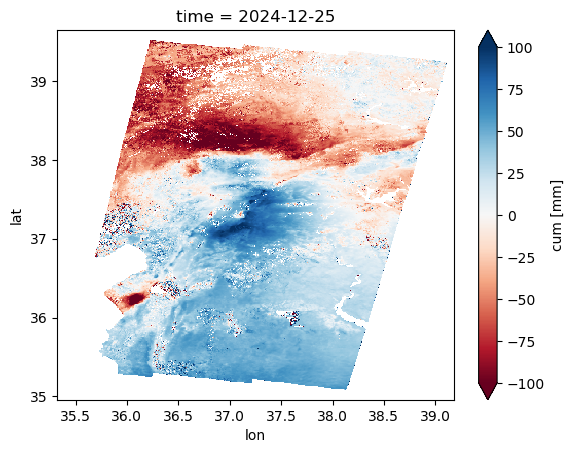

In [5]:
cum_uncor.cum[-1].plot(vmin=-100, vmax=100, cmap="RdBu")

In [13]:
if sbovl:
    vars_to_ref = ["cum", "iono", "tide"]
else:
    vars_to_ref = ["cum", "iono", "tide", "sltd"]

cum_cor_ref = reference_ts_dataset(
    cum_cor,
    reference=reference,
    vars_to_ref=vars_to_ref,
    use_nearest=False,
    halfwin=4,
    verbose=True
)

cum_uncor_ref = reference_ts_dataset(
    cum_uncor,
    reference=reference,
    vars_to_ref=vars_to_ref,
    use_nearest=False,
    halfwin=4,
    verbose=True
)

Referenced 'cum' using ±4 pixel window
Referenced 'iono' using ±4 pixel window
Referenced 'tide' using ±4 pixel window
Referenced 'sltd' using ±4 pixel window
Referenced 'cum' using ±4 pixel window
Referenced 'iono' using ±4 pixel window
Referenced 'tide' using ±4 pixel window
Referenced 'sltd' using ±4 pixel window


In [10]:
##plate motion and interseismic effect
#plate motion
vlos_eurasia = generate_pmm_velocity(frame, 'Eurasia', 'GEOC', azi=sbovl)
# #reshape
vlos_eurasia_reshaped=vlos_eurasia.interp_like(cum_cor.vel)
plate_motion_cumulative = vlos_eurasia_reshaped * years

#interseismic model
ve_gnss_nc='/gws/ssde/j25a/nceo_geohazards/vol1/projects/COMET/mnergizci/1.second_paper/interseismic/decomp3d.nc'
vn_gnss_nc='/gws/ssde/j25a/nceo_geohazards/vol1/projects/COMET/mnergizci/1.second_paper/interseismic/velmap_insars29_sbois0_scalar.nc'

#ENU unit vectors
if sbovl:
    E_unit=load_tif2xr(f'{path}/{frame}.E.azi.geo.tif')
    N_unit=load_tif2xr(f'{path}/{frame}.N.azi.geo.tif')
    # azimuth has no vertical sensitivity
    U_unit = xr.zeros_like(E_unit)
else:
    E_unit=load_tif2xr(f'{path}/{frame}.E.geo.tif')
    N_unit=load_tif2xr(f'{path}/{frame}.N.geo.tif')
    U_unit=load_tif2xr(f'{path}/{frame}.U.geo.tif')

#load interseismic model
ve_gnss= xr.load_dataset(ve_gnss_nc).Ve
vn_gnss= xr.load_dataset(vn_gnss_nc).Vn

##reshape
ve_gnss_reshaped=ve_gnss.interp_like(E_unit)
vn_gnss_reshaped=vn_gnss.interp_like(E_unit)

interseismic_velo = ve_gnss_reshaped * E_unit + vn_gnss_reshaped * N_unit
interseismic_velo_cumulative = interseismic_velo*years

##reference
plate_motion_cumulative_ref = spatial_reference_2d(
    plate_motion_cumulative, reference, use_nearest=False
)
plate_motion_cumulative_ref=plate_motion_cumulative_ref.interp_like(E_unit)


interseismic_velo_cumulative_ref = spatial_reference_2d(
    interseismic_velo_cumulative, reference, use_nearest=False
)
interseismic_velo_cumulative_ref=interseismic_velo_cumulative_ref.interp_like(E_unit)


assume a spheroidal Earth as defined in WGS84
Interpolating the plate velocity ENU vectors to the original frame resolution
Calculating the plate motion velocity in LOS (please check the sign here)


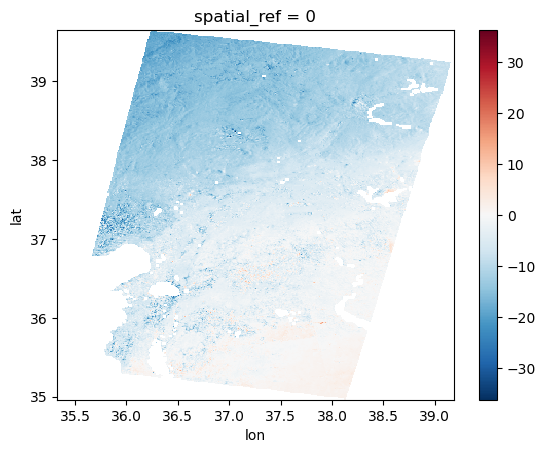

In [36]:
interseismic_velo_cumulative_ref.plot()

In [39]:
sltd_ts

<xarray.DataArray 'sltd' (time: 53)> Size: 212B
array([   0.        ,    6.3953724 ,   10.896762  ,   27.654314  ,
         13.302776  ,  -27.768078  ,  -30.920399  ,  -51.980835  ,
         -8.19541   ,  -35.006584  ,  -36.450653  ,  -77.475685  ,
         -3.5038853 ,  -79.26811   ,  -77.805016  , -143.4694    ,
         -5.7784796 ,   -0.42006952,   45.345787  ,   64.0004    ,
         10.702497  ,   37.85473   ,  -13.066417  ,   40.458683  ,
        -38.799637  ,  -31.05136   ,   24.060421  ,   61.2834    ,
         28.970325  ,   17.03687   ,  -24.542707  ,  -23.045347  ,
         10.8927965 ,  -68.67599   ,   -3.752598  ,  -19.078098  ,
          3.6649814 ,   -6.2840743 ,  -60.651676  ,  -93.984535  ,
        -13.441889  ,   35.510075  ,   42.841644  ,   19.789436  ,
         -4.616509  ,    7.2113867 ,   53.65384   ,    6.6446652 ,
         19.688738  ,  -23.011023  ,   73.87885   ,   33.52816   ,
        -30.096481  ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 424B 2023-02-10 2023-02-22 ... 2024-12-25

In [37]:
interseismic_ts = extract_ts_window_mean(interseismic_velo_cumulative_ref, point1, halfwin=4)

In [44]:
# extract time series at point1 using ±4 pixels
tide_ts = extract_ts_window_mean(cum_uncor_ref["tide"], point1, halfwin=4)
iono_ts = extract_ts_window_mean(cum_uncor_ref["iono"], point1, halfwin=4)
cum_cor_ts  = extract_ts_window_mean(cum_cor_ref["cum"],  point1, halfwin=4)
cum_uncor_ts = extract_ts_window_mean(cum_uncor_ref["cum"], point1, halfwin=4)
time = cum_uncor_ref.time
sltd_ts = extract_ts_window_mean(cum_uncor_ref["sltd"], point1, halfwin=4)
interseismic_ts = extract_ts_window_mean(interseismic_velo_cumulative_ref, point1, halfwin=4)
plate_motion_ts = extract_ts_window_mean(plate_motion_cumulative_ref, point1, halfwin=4)

In [45]:
plate_motion_ts

<xarray.DataArray ()> Size: 8B
array(2.57531376)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:     Point
    TIFFTAG_DATETIME:  2023:02:06 19:15:00
    TIFFTAG_SOFTWARE:  Created with GAMMA Software www.gamma-rs.ch data2geoti...
    _FillValue:        0.0
    scale_factor:      1.0
    add_offset:        0.0

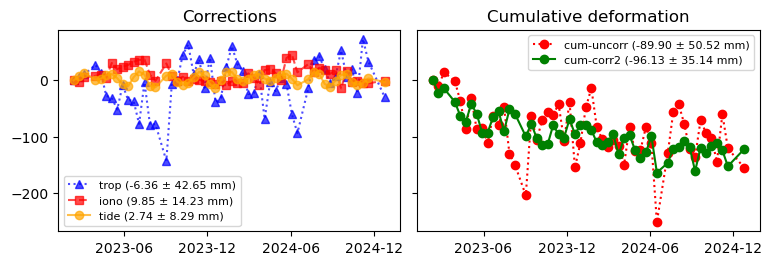

In [16]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Times New Roman"],   # common journal style
#     "font.size": 9,                      # base size
#     "axes.labelsize": 9,
#     "axes.titlesize": 10,
#     "xtick.labelsize": 8,
#     "ytick.labelsize": 8,
#     "legend.fontsize": 8,
#     "axes.linewidth": 0.8,
#     "lines.linewidth": 1.2,
#     "lines.markersize": 4,
# })

cm = 1 / 2.54  # inches per cm

fig, ax = plt.subplots(1, 2, figsize=(20*cm, 7*cm), sharex=True, sharey=True)

##statistics
#mean
# if sbovl:
#     cum_uncor_ts = cum_cor_ts + tide_ts + iono_ts
# else:
mean_trop = np.nanmean(sltd_ts)
std_trop = np.nanstd(sltd_ts)
cum_cor_ts2 = cum_uncor_ts - sltd_ts - tide_ts - iono_ts
#mean
mean_iono = np.nanmean(iono_ts)
mean_tide = np.nanmean(tide_ts)
mean_uncor_cum = np.nanmean(cum_uncor_ts)
mean_cum = np.nanmean(cum_cor_ts)
mean_cum2 = np.nanmean(cum_cor_ts2)
#std
std_iono = np.nanstd(iono_ts)
std_tide = np.nanstd(tide_ts)
std_uncor_cum = np.nanstd(cum_uncor_ts)
std_cum = np.nanstd(cum_cor_ts)
std_cum2 = np.nanstd(cum_cor_ts2)




# ---- Left panel: corrections ----
plt.rcParams["legend.fontsize"] = 8
if sbovl==False:
    ax[0].plot(time, sltd_ts, color="blue", marker="^", linestyle=":", alpha=0.7, label=f"trop ({mean_trop:.2f} ± {std_trop:.2f} mm)")
ax[0].plot(time, iono_ts, color="red", marker="s", linestyle="--", alpha=0.7, label=f"iono ({mean_iono:.2f} ± {std_iono:.2f} mm)")
ax[0].plot(time, tide_ts, color="orange", marker="o", linestyle="-", alpha=0.7, label=f"tide ({mean_tide:.2f} ± {std_tide:.2f} mm)")

# ax[0].set_ylabel("Displacement (mm)")
ax[0].set_title("Corrections")
ax[0].legend()

# ---- Right panel: cumulative deformation ----
ax[1].plot(time, cum_uncor_ts, color="red", marker="o", linestyle=":", label=f"cum-uncorr ({mean_uncor_cum:.2f} ± {std_uncor_cum:.2f} mm)")
# ax[1].plot(time, cum_cor_ts, color="black", marker="o", linestyle="-", label=f"cum-corr ({mean_cum:.2f} ± {std_cum:.2f} mm)")
ax[1].plot(time, cum_cor_ts2, color="green", marker="o", linestyle="-", label=f"cum-corr2 ({mean_cum2:.2f} ± {std_cum2:.2f} mm)")

ax[1].set_title("Cumulative deformation")
ax[1].legend()

# hide y tick labels on second plot
ax[1].tick_params(labelleft=False)

# ----- Sparse x-axis ticks -----
locator = mdates.MonthLocator(interval=6)   # every 3 months
formatter = mdates.DateFormatter('%Y-%m')

for a in ax:
    a.xaxis.set_major_locator(locator)
    a.xaxis.set_major_formatter(formatter)

# # shared x label
# fig.supxlabel("Time")

plt.tight_layout()
# reduce space between panels
fig.subplots_adjust(wspace=0.05)
# if sbovl==False:
#     # plt.savefig("Figure3_cumulative_corrections_range_raw_time_series.png", dpi=300)
# else:
    # plt.savefig("Figure3_cumulative_corrections_sboi_raw_time_series.png", dpi=300)
plt.show()

In [51]:
cum_minus_all[-1]

<xarray.DataArray ()> Size: 8B
array(-112.39101119)
Coordinates:
    time         datetime64[ns] 8B 2024-12-25
    spatial_ref  int64 8B 0
Attributes:
    unit:     mm

(a) Uncorrected: mean=-89.90 mm, std=50.52 mm, slope=-1.4356 mm/day
1050
(b) Uncorrected - tropo: mean=-83.54 mm, std=40.18 mm, slope=-2.0547 mm/day
800
(c) Uncorrected - tropo - iono: mean=-93.39 mm, std=37.03 mm, slope=-1.9365 mm/day
600
(d) Uncorrected - tropo - iono - tide: mean=-96.13 mm, std=35.14 mm, slope=-1.8838 mm/day
400
(e) Uncorrected - tropo - iono - tide - plate motion: mean=-98.71 mm, std=35.14 mm, slope=-1.8838 mm/day
200
(f) Uncorrected - tropo - iono - tide - plate motion - interseismic: mean=-86.17 mm, std=35.14 mm, slope=-1.8838 mm/day
0


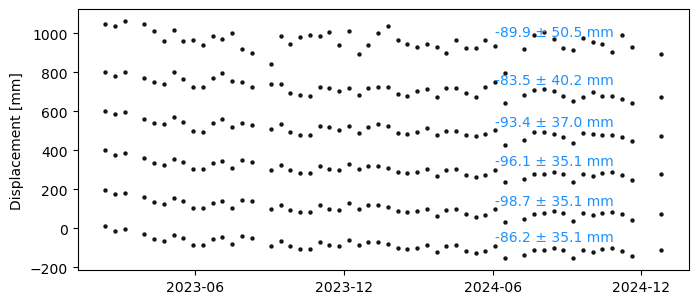

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

cm = 1 / 2.54

# progressive corrections
cum_uncor_only   = cum_uncor_ts
cum_minus_tropo  = cum_uncor_ts - sltd_ts
cum_minus_tr_ion = cum_uncor_ts - sltd_ts - iono_ts
cum_minus_tr_ion_tide = cum_uncor_ts - sltd_ts - iono_ts - tide_ts
cum_minus_tr_ion_tide_plate = cum_uncor_ts - sltd_ts - iono_ts - tide_ts - plate_motion_ts
cum_minus_all    = cum_uncor_ts - sltd_ts - iono_ts - tide_ts - plate_motion_ts - interseismic_ts

series = [
    ("(a) Uncorrected", cum_uncor_only),
    ("(b) Uncorrected - tropo", cum_minus_tropo),
    ("(c) Uncorrected - tropo - iono", cum_minus_tr_ion),
    ("(d) Uncorrected - tropo - iono - tide", cum_minus_tr_ion_tide),
    ("(e) Uncorrected - tropo - iono - tide - plate motion", cum_minus_tr_ion_tide_plate),
    ("(f) Uncorrected - tropo - iono - tide - plate motion - interseismic", cum_minus_all),
]

# vertical offsets only for display, like your example figure
offset_step =  200  # mm
offsets = np.arange(len(series))[::-1] * offset_step

fig, ax = plt.subplots(figsize=(18*cm, 8*cm))

for i, ((label, y), off) in enumerate(zip(series, offsets)):
    vel = np.polyfit(np.arange(len(y)), y, 1)[0]  # optional simple slope/index
    std = np.nanstd(y)
    print(f"{label}: mean={np.nanmean(y):.2f} mm, std={std:.2f} mm, slope={vel:.4f} mm/day")
    if i == 0:
        off = 1050
    print(off)
    ax.plot(
        time, y + off,
        linestyle="None",
        marker="o",
        markersize=2.2,
        color="black",
        alpha=0.85
    )

    # # left-side labels
    # ax.text(
    #     time[2], off + np.nanmedian(y) + 8,
    #     label,
    #     fontsize=10,
    #     ha="left",
    #     va="bottom",
    #     color="dimgray"
    # )

    # right-side stats
    ax.text(
        time[int(len(time)*0.72)],
        off + np.nanmedian(y) + 8,
        f"{np.nanmean(y):.1f} ± {std:.1f} mm",
        fontsize=10,
        color="dodgerblue",
        ha="left",
        va="bottom"
    )

ax.set_ylabel("Displacement [mm]")

locator = mdates.MonthLocator(interval=6)
formatter = mdates.DateFormatter("%Y-%m")
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

ax.tick_params(axis="x", rotation=0)
ax.grid(False)
plt.tight_layout()
plt.show()

(a) Uncorrected: cumulative=-155.82 mm, velocity=-82.01 mm/yr, std=50.52 mm
(b) Uncorrected - tropo: cumulative=-125.73 mm, velocity=-66.17 mm/yr, std=40.18 mm
(c) Uncorrected - tropo - iono: cumulative=-125.29 mm, velocity=-65.94 mm/yr, std=37.03 mm
(d) Uncorrected - tropo - iono - tide: cumulative=-122.35 mm, velocity=-64.40 mm/yr, std=35.14 mm
(e) Uncorrected - tropo - iono - tide - plate motion: cumulative=-122.35 mm, velocity=-64.40 mm/yr, std=35.14 mm
(f) Uncorrected - tropo - iono - tide - plate motion - interseismic: cumulative=-122.35 mm, velocity=-64.40 mm/yr, std=35.14 mm


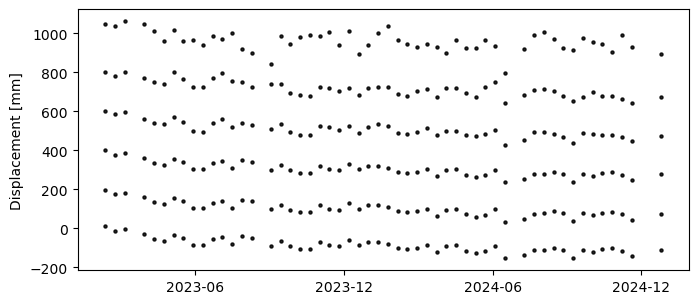

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

cm = 1 / 2.54

# -----------------------------
# Progressive corrected series
# -----------------------------
cum_uncor_only = cum_uncor_ts
cum_minus_tropo = cum_uncor_ts - sltd_ts
cum_minus_tr_ion = cum_uncor_ts - sltd_ts - iono_ts
cum_minus_tr_ion_tide = cum_uncor_ts - sltd_ts - iono_ts - tide_ts
cum_minus_tr_ion_tide_plate = (
    cum_uncor_ts - sltd_ts - iono_ts - tide_ts - plate_motion_ts
)
cum_minus_all = (
    cum_uncor_ts - sltd_ts - iono_ts - tide_ts - plate_motion_ts - interseismic_ts
)

series = [
    ("(a) Uncorrected", cum_uncor_only),
    ("(b) Uncorrected - tropo", cum_minus_tropo),
    ("(c) Uncorrected - tropo - iono", cum_minus_tr_ion),
    ("(d) Uncorrected - tropo - iono - tide", cum_minus_tr_ion_tide),
    ("(e) Uncorrected - tropo - iono - tide - plate motion", cum_minus_tr_ion_tide_plate),
    ("(f) Uncorrected - tropo - iono - tide - plate motion - interseismic", cum_minus_all),
]

# -----------------------------
# Figure and display offsets
# -----------------------------
offset_step = 200  # mm
offsets = np.arange(len(series))[::-1] * offset_step

fig, ax = plt.subplots(figsize=(18 * cm, 8 * cm))

# -----------------------------
# Plot each stacked time series
# -----------------------------
for i, ((label, y), off) in enumerate(zip(series, offsets)):
    y = np.asarray(y, dtype=float)

    # cumulative displacement between first and last epoch
    cum_disp = y[-1] - y[0]

    # optional variability estimate
    std = np.nanstd(y)


    vel_mmyr = cum_disp / 1.9

    print(
        f"{label}: cumulative={cum_disp:.2f} mm, "
        f"velocity={vel_mmyr:.2f} mm/yr, std={std:.2f} mm"
    )

    # optional manual shift for the first row
    if i == 0:
        off = 1050

    ax.plot(
        time,
        y + off,
        linestyle="None",
        marker="o",
        markersize=2.2,
        color="black",
        alpha=0.85,
    )

    # # left-side labels
    # ax.text(
    #     time[2],
    #     off + np.nanmedian(y) + 8,
    #     label,
    #     fontsize=10,
    #     ha="left",
    #     va="bottom",
    #     color="dimgray",
    # )

    # # right-side cumulative displacement text
    # ax.text(
    #     time[int(len(time) * 0.72)],
    #     off + np.nanmedian(y) + 8,
    #     f"{cum_disp:.1f} mm",
    #     fontsize=10,
    #     color="dodgerblue",
    #     ha="left",
    #     va="bottom",
    # )

# -----------------------------
# Axis formatting
# -----------------------------
ax.set_ylabel("Displacement [mm]")

locator = mdates.MonthLocator(interval=6)
formatter = mdates.DateFormatter("%Y-%m")
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

ax.tick_params(axis="x", rotation=0)
ax.grid(False)

plt.tight_layout()
plt.show()